## Order & Product Profitability Risk Modeling

### Notebook 4 — Modeling & Evaluation

#### Objective
Build and evaluate machine learning models to predict profitability risk and identify key drivers of low-profit orders.

#### Key Tasks
- Train baseline model (Logistic Regression)
- Evaluate model performance
- Train improved model (Random Forest)
- Compare models
- Interpret results

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("../data/processed/model_data.csv")
df.head()

,total_sales,total_discount,total_quantity,profit_risk,Customer Segment_Corporate,Customer Segment_Home Office,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,...,Order Region_West Africa,Order Region_West Asia,Order Region_West of USA,Order Region_Western Europe,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,discount_pct,avg_price_per_item,discount_per_item
0,299.980011,60.000000,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0.200013,299.980011,60.000000
1,579.980011,50.600000,7,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0.087244,82.854287,7.228571
2,699.850010,78.980000,14,0,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0.112853,49.989286,5.641429
3,1129.860039,142.789999,10,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0.126378,112.986004,14.279000
4,579.920013,54.400000,7,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0.093806,82.845716,7.771429


In [21]:
df.columns

Index(['total_sales', 'total_discount', 'total_quantity', 'profit_risk',
       'Customer Segment_Corporate', 'Customer Segment_Home Office',
       'Market_Europe', 'Market_LATAM', 'Market_Pacific Asia', 'Market_USCA',
       'Order Region_Caribbean', 'Order Region_Central Africa',
       'Order Region_Central America', 'Order Region_Central Asia',
       'Order Region_East Africa', 'Order Region_East of USA',
       'Order Region_Eastern Asia', 'Order Region_Eastern Europe',
       'Order Region_North Africa', 'Order Region_Northern Europe',
       'Order Region_Oceania', 'Order Region_South America',
       'Order Region_South Asia', 'Order Region_South of  USA ',
       'Order Region_Southeast Asia', 'Order Region_Southern Africa',
       'Order Region_Southern Europe', 'Order Region_US Center ',
       'Order Region_West Africa', 'Order Region_West Asia',
       'Order Region_West of USA ', 'Order Region_Western Europe',
       'Shipping Mode_Same Day', 'Shipping Mode_Second Class

In [3]:
X = df.drop('profit_risk', axis=1)
y = df['profit_risk']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
X_train.shape, X_test.shape

((52601, 37), (13151, 37))

In [7]:
y_train.value_counts(normalize=True)

profit_risk
0    0.749548
1    0.250452
Name: proportion, dtype: float64

### 1. Baseline Model — Logistic Regression

Logistic Regression is used as a baseline model to establish initial performance. It is simple, interpretable, and helps understand how well the features capture profitability risk.

In [ ]:
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

model_lr.fit(X_train, y_train)

c:\Users\Abdul Basit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [18]:
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.78      0.55      0.65      9887
           1       0.28      0.51      0.36      3264

    accuracy                           0.54     13151
   macro avg       0.53      0.53      0.50     13151
weighted avg       0.65      0.54      0.57     13151



In [20]:
roc_auc_score(y_test, y_prob_lr)

0.5564587560016421

In [ ]:

model_rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [10]:
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

In [11]:
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85      9887
           1       0.42      0.12      0.19      3264

    accuracy                           0.74     13151
   macro avg       0.59      0.53      0.52     13151
weighted avg       0.68      0.74      0.68     13151

ROC AUC Score: 0.5435940372533155


### Feature Importance Analysis

In [12]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

discount_pct                    0.150830
total_discount                  0.148876
discount_per_item               0.147744
total_sales                     0.146985
avg_price_per_item              0.139836
total_quantity                  0.061884
Customer Segment_Corporate      0.025801
Shipping Mode_Standard Class    0.021666
Customer Segment_Home Office    0.021139
Shipping Mode_Second Class      0.015707
Shipping Mode_Same Day          0.008277
Order Region_Western Europe     0.007477
Market_Europe                   0.006697
Order Region_Oceania            0.005986
Order Region_Central America    0.005957
dtype: float64

<Axes: >

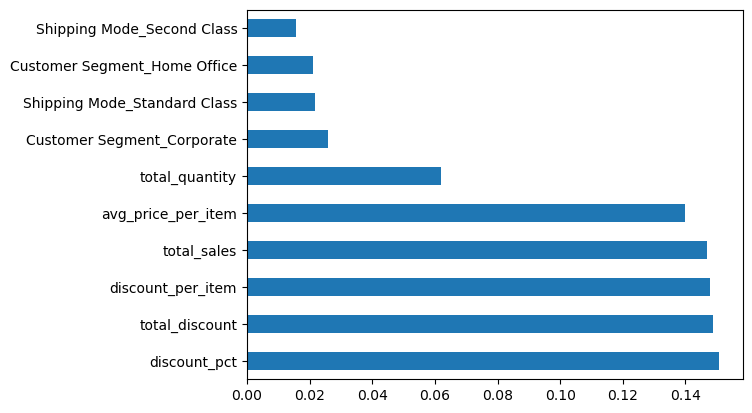

In [13]:
feature_importance.head(10).plot(kind='barh')

**Observation:**

Feature importance analysis shows that pricing and discount-related features (such as discount percentage, total discount, and average price per item) contribute the most to the model’s predictions. 

In contrast, most categorical features such as region, market, and shipping mode have very low importance scores, indicating that they add limited predictive value in this dataset.

This suggests that the model primarily relies on pricing-related factors to identify profitability risk.

In [14]:
selected_features = [
    'total_sales',
    'total_discount',
    'total_quantity',
    'discount_pct',
    'avg_price_per_item',
    'discount_per_item'
]

In [19]:
X_selected = df[selected_features]
y = df['profit_risk']

In [20]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [ ]:
#Random Forest with selected features
model_rf2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

model_rf2.fit(X_train2, y_train2)

y_pred2 = model_rf2.predict(X_test2)
y_prob2 = model_rf2.predict_proba(X_test2)[:, 1]


In [26]:
print(classification_report(y_test2, y_pred2))

print("ROC AUC Score:", roc_auc_score(y_test2, y_prob2))

              precision    recall  f1-score   support

           0       0.77      0.93      0.84      9887
           1       0.44      0.17      0.25      3264

    accuracy                           0.74     13151
   macro avg       0.61      0.55      0.55     13151
weighted avg       0.69      0.74      0.70     13151

ROC AUC Score: 0.5671662550298768


**Observation:**

After removing low-importance features and retraining the model using only key pricing-related features, there is a noticeable improvement in recall for risky orders. However, the overall performance improvement is limited.

This indicates that while feature selection helps reduce noise, the available features still do not strongly separate risky and non-risky orders. The model continues to struggle in identifying profitability risk effectively.

This suggests that additional or more informative features may be required to significantly improve prediction performance.

In [ ]:
#Logistic Regression with selected features
model_lr2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr2.fit(X_train2, y_train2)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
y_pred_lr2 = model_lr2.predict(X_test2)
y_prob_lr2 = model_lr2.predict_proba(X_test2)[:, 1]

In [30]:
print(classification_report(y_test2, y_pred_lr2))   

print("ROC AUC Score:", roc_auc_score(y_test2, y_prob_lr2))

              precision    recall  f1-score   support

           0       0.78      0.53      0.63      9887
           1       0.28      0.54      0.37      3264

    accuracy                           0.54     13151
   macro avg       0.53      0.54      0.50     13151
weighted avg       0.66      0.54      0.57     13151

ROC AUC Score: 0.5649494155278172


### Model Comparison

Two models were evaluated for predicting profitability risk:

- Logistic Regression (with class balancing) achieved higher recall (~54%), making it more effective at identifying risky orders. However, it suffers from low precision, resulting in many false positives.

- Random Forest achieved higher precision (~44%) and slightly better ROC-AUC, but has much lower recall (~17%), meaning it misses a large number of risky orders.

This highlights a clear trade-off between recall and precision. In a business context where missing risky orders can lead to financial loss, Logistic Regression may be more suitable despite its lower precision.

However, the overall performance of both models remains moderate, indicating that the available features have limited predictive power.

## Final Insights

### Key Findings

- Profitability risk is mainly driven by pricing and discount-related factors.
- Features like discount percentage, total discount, and average price per item have the highest impact on model predictions.
- Geographic and operational features (region, market, shipping) contribute very little in this dataset.

---

### Model Insights

- Logistic Regression achieved higher recall (~54%), making it better at identifying risky orders, but with many false positives.
- Random Forest achieved better precision but failed to detect many risky orders.
- Overall model performance is moderate, with ROC-AUC around 0.56, indicating limited predictive power.

---

### Business Implications

- High discounts and pricing decisions are key drivers of low profitability.
- Businesses should monitor and control discount strategies to reduce loss-making orders.
- Even simple rules based on discount levels could help in identifying risky orders.

---

### Limitations

- The dataset lacks important variables such as cost, logistics expenses, and operational details.
- Model performance is limited by available features rather than model choice.
- The models built here are not strong enough for direct production use.

---

### Final Conclusion

This project demonstrates that while machine learning can help identify profitability risk patterns, its effectiveness depends heavily on data quality and feature availability.

With the current dataset, we were able to extract meaningful insights, but more detailed and relevant data would be required to build a reliable predictive system.